In [32]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm

## DAÑO DE LA RED

In [33]:
# --- FUNCIONES DE DAÑO ---
def update_damage_matrix(h_matrix, adjacency_matrix):
    edges = np.argwhere(adjacency_matrix > 0)
    h_values = np.array([h_matrix[i, j] for i, j in edges])
    prob = h_values / np.sum(h_values)
    idx = np.random.choice(len(edges), p=prob)
    h_matrix[edges[idx][0], edges[idx][1]] += 1
    return h_matrix

def get_omega_matrix(h_matrix, adjacency_matrix, alpha):
    return (h_matrix.astype(float) ** (-alpha)) * adjacency_matrix

# --- FUNCIONES DE CALCULO DE AUTOVALORES ---

def Laplaciano(M):
    S = M.sum(axis=1)

    # Construir el Laplaciano: L = diag(S) - M
    # np.diag(S) crea la matriz con S_i en la diagonal principal (S_i * delta_ij)
    L = np.diag(S) - M

    return L

def get_second_eigenvalue_real(M):

    L = Laplaciano(M)

    #Calcular autovalores
    evals = np.linalg.eigvals(L)

    # Extraer partes reales y ordenar
    real_parts = np.sort(np.real(evals))

    # Retornamos el segundo autovalor
    return real_parts[1]

# --- FUNCIONES DE SINCRONIZACIÓN ---

def evolucion_fases(M, t, theta_0):
    """
    Calcula la evolución de las fases de cada nodo en el tiempo t.
    M: Matriz de acoplamiento (Omega)
    t: Escalar o array de tiempos
    theta_0: Vector de fases iniciales (condiciones iniciales)
    """
    L = Laplaciano(M)

    # Si t es un solo valor (escalar)
    if np.isscalar(t):
        matriz_evolucion = expm(-t * L)
        return matriz_evolucion @ theta_0

    # Si t es un array de tiempos, calculamos la fase para cada paso
    else:
        fases_historial = []
        for ti in t:
            matriz_evolucion = expm(-ti * L)
            fases_historial.append(matriz_evolucion @ theta_0)
        return np.array(fases_historial)

def order_parameter_evolucion(fases_t):
    return np.array([np.abs(np.mean(np.exp(1j * f))) for f in fases_t])

# --- FUNCIONES DE SIMULACION ---

def Simulacion_damage(A, alpha, T_repair, theta_0):
    """
    Solo corre la fase de daño y devuelve el estado final h, tau_0 y la funcionalidad.
    """
    N = A.shape[0]
    h = np.ones((N, N))
    tau_0 = None
    funcionalidad = np.zeros(T_repair + 1)  # <-- nuevo

    for T_step in range(T_repair + 1):
        Omega = get_omega_matrix(h, A, alpha)
        xi2 = get_second_eigenvalue_real(Omega)
        tau_T = 1.0 / xi2

        if T_step == 0:
            tau_0 = tau_T

        funcionalidad[T_step] = tau_0 / tau_T  # <-- nuevo

        if T_step < T_repair:
            h = update_damage_matrix(h, A)

    return h, tau_0, funcionalidad, Omega  # <-- nuevo

#-------------------------------------------RED CON DOS COMUNIDADES-------------------------------------------

def Two_Communities_random(n, p):
    sizes = [n, n]  # dos comunidades
    # Probabilidades de conexión
    p_in = 1-p        # intra-comunidad
    p_out = p     # inter-comunidad
    # Matriz de probabilidades
    probs = [[p_in, p_out],[p_out, p_in]]
    # Generar red SBM
    G = nx.stochastic_block_model(sizes, probs, seed=42) #Quitar seed si quieres redes aleatorias
    return G




--- Tiempo total: 1.15 minutos ---


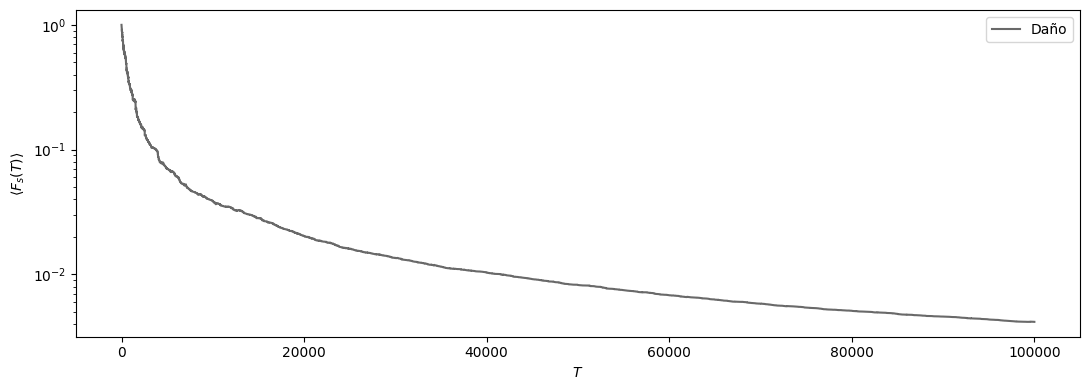

In [34]:
# --- PARÁMETROS ---
num_simulations = 1
alpha_damage = 1.0
T_Max = 100000
N = 10
G = Two_Communities_random(N, 0.1)
A = nx.to_numpy_array(G)


# --- ACUMULADORES ---
avg_damage = np.zeros(T_Max + 1)

start_time_total = time.time()

# --- BUCLE DE SIMULACIONES ---
for sim in range(num_simulations):
    theta_0 = np.random.uniform(0, 2 * np.pi, N)

    # Fase de daño (única y compartida para todos los alpha_repair)
    h_damaged, tau_0, f_damage, Omega_damage = Simulacion_damage(A, alpha_damage, T_Max, theta_0)
    avg_damage += f_damage

    if (sim + 1) % 10 == 0:
        print(f"  Simulación {sim+1}/{num_simulations} lista.")

# --- PROMEDIOS ---
avg_damage /= num_simulations

print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")

# --- GRÁFICA ---
t_damage = np.arange(T_Max + 1)




plt.figure(figsize=(11, 4))

plt.semilogy(t_damage, avg_damage,
         color='dimgray', linewidth=1.5, label='Daño')

plt.xlabel("$T$")
plt.ylabel(r"$\left\langle F_s(T) \right\rangle$")
plt.legend()
plt.tight_layout()
plt.show()

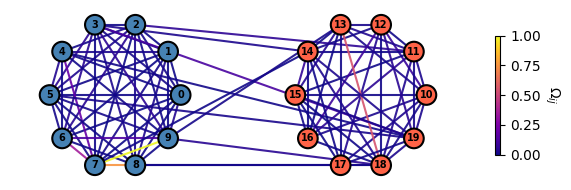

In [48]:
# --- GRÁFICA DE LA RED DAÑADA ---

# 1. Posiciones en dos círculos
N_com = N
pos = {}
for i, node in enumerate(range(N_com)):
    angle = 2 * np.pi * i / N_com
    pos[node] = np.array([-1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])
for i, node in enumerate(range(N_com, 2 * N_com)):
    angle = 2 * np.pi * i / N_com
    pos[node] = np.array([1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])

# 2. Pesos de enlaces
edges = list(G.edges())
weights = np.array([Omega_damage[u, v] for u, v in edges])
w_max = weights.max() if weights.max() > 0 else 1

# 3. Dibujar
fig, ax = plt.subplots(figsize=(6, 2))

node_colors = ['steelblue'] * N_com + ['tomato'] * N_com
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=200, node_color=node_colors,
                       edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges,
                       width=1.5,
                       edge_color=weights, edge_cmap=plt.cm.plasma,
                       alpha=0.9, edge_vmin=0, edge_vmax=w_max)

# 4. Barra de color
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label(r'$\Omega_{ij}$', rotation=270, labelpad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

## **REPARACIÓN DE LA RED**

In [36]:
def _seleccionar_enlace(Omega_matrix, strategy):
    """
    Devuelve las coordenadas (i, j) del enlace a reparar según strategy.
    Retorna None si no hay enlaces dañados.
    """
    edges = np.argwhere(Omega_matrix > 0)
    Omega_values = np.array([Omega_matrix[i, j] for i, j in edges])

    mask = Omega_values < 1.0
    if not np.any(mask):
        return None

    edges_reparables = edges[mask]
    Omega_reparables = Omega_values[mask]

    if strategy == 'best':
        idx = np.argmax(Omega_reparables)
    elif strategy == 'worst':
        idx = np.argmin(Omega_reparables)

    return edges_reparables[idx]

def Simulacion_repair_deterministic(A, Omega_damage, T_repair, delta_r, strategy='best'):
    tau_0 = 1.0 / get_second_eigenvalue_real(A)
    Omega = Omega_damage.copy()
    funcionalidad = np.zeros(T_repair + 1)

    # Variables para trackear el máximo
    F_max = -np.inf
    Omega_at_Fmax = Omega.copy()

    enlace_actual = _seleccionar_enlace(Omega, strategy)

    for T_step in range(T_repair + 1):
        xi2 = get_second_eigenvalue_real(Omega)
        tau_T = 1.0 / xi2
        F_s = tau_0 / tau_T
        funcionalidad[T_step] = F_s

        # Guardar Omega si es el máximo hasta ahora
        if F_s > F_max:
            F_max = F_s
            Omega_at_Fmax = Omega.copy()

        if T_step < T_repair:
            if enlace_actual is None:
                funcionalidad[T_step + 1:] = funcionalidad[T_step]
                break

            i, j = enlace_actual
            Omega[i, j] = min(Omega[i, j] + delta_r, 1.0)

            if Omega[i, j] >= 1.0:
                enlace_actual = _seleccionar_enlace(Omega, strategy)

    return funcionalidad, Omega_at_Fmax, F_max





--- Tiempo total: 0.02 minutos ---


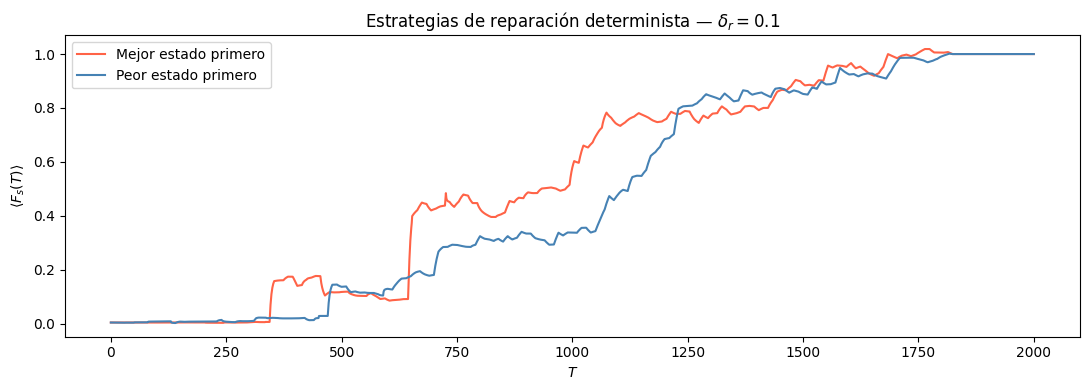

In [37]:
# --- PARÁMETROS ---
num_simulations = 1
T_repair = 2000
delta_r = 0.1
strategies = ['best', 'worst']

strategy_config = {
    'best':  ('Mejor estado primero', 'tomato'),
    'worst': ('Peor estado primero',  'steelblue'),
}

# --- ACUMULADORES ---
avg_repair = {s: np.zeros(T_repair + 1) for s in strategies}

start_time_total = time.time()

# --- BUCLE DE SIMULACIONES ---
for sim in range(num_simulations):
    for s in strategies:
        f_repair, _, _ = Simulacion_repair_deterministic(A, Omega_damage, T_repair, delta_r, strategy=s)
        avg_repair[s] += f_repair

    if (sim + 1) % 10 == 0:
        print(f"  Simulación {sim+1}/{num_simulations} lista.")

# --- PROMEDIOS ---
for s in strategies:
    avg_repair[s] /= num_simulations

print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")

# --- GRÁFICA ---
t_repair = np.arange(T_repair + 1)

plt.figure(figsize=(11, 4))
for s in strategies:
    label, color = strategy_config[s]
    plt.plot(t_repair, avg_repair[s],
             color=color, linewidth=1.5, label=label)

plt.xlabel("$T$")
plt.ylabel(r"$\left\langle F_s(T) \right\rangle$")
plt.title(f"Estrategias de reparación determinista — $\\delta_r = {delta_r}$")
plt.legend()
plt.tight_layout()
plt.show()


--- Tiempo total: 0.21 minutos ---


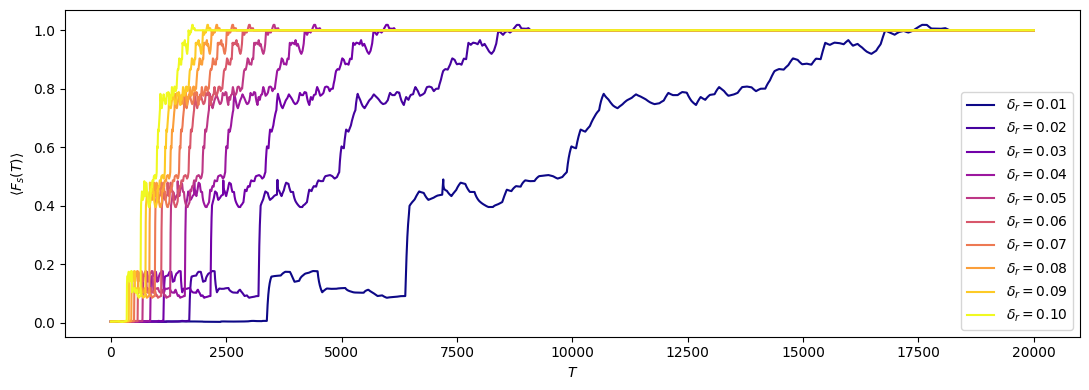

In [59]:
# --- PARÁMETROS ---
num_simulations = 1
T_repair = 20000
deltas_r = np.linspace(0.01, 0.1, 10)
#deltas_r = np.array([0.1])

# --- ACUMULADORES ---
avg_repair = {d: np.zeros(T_repair + 1) for d in deltas_r}

start_time_total = time.time()

# --- BUCLE DE SIMULACIONES ---
for sim in range(num_simulations):
    for d in deltas_r:
        f_repair, _, _ = Simulacion_repair_deterministic(A, Omega_damage, T_repair, d, strategy='best')
        avg_repair[d] += f_repair

    if (sim + 1) % 10 == 0:
        print(f"  Simulación {sim+1}/{num_simulations} lista.")

# --- PROMEDIOS ---
for d in deltas_r:
    avg_repair[d] /= num_simulations

print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")

# --- GRÁFICA ---
t_repair = np.arange(T_repair + 1)

colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

plt.figure(figsize=(11, 4))
for d in deltas_r:
    color = colormap(norm(d))
    plt.plot(t_repair, avg_repair[d],
             color=color, linewidth=1.5, label=f'$\\delta_r = {d:.2f}$')

plt.xlabel("$T$")
plt.ylabel(r"$\left\langle F_s(T) \right\rangle$")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
for d in deltas_r:
    print(f"{d} : {np.max(avg_repair[d])}")

0.01 : 1.0186471742646013
0.02 : 1.0186471742646013
0.03 : 1.0186471742646008
0.04 : 1.0186471742646002
0.05 : 1.0186471742646006
0.06 : 1.0186471742646002
0.07 : 1.0186471742646
0.08 : 1.0186471742646002
0.09 : 1.0186471742646002
0.1 : 1.018647174264599


In [44]:
for d in deltas_r:
    arr = avg_repair[d]
    indices = np.where(arr >= 1.0)[0]
    if len(indices) > 0:
        primer_indice = indices[0]
        print(f"delta_r = {d:.3f} → F_s = 1.0 alcanzado en T = {primer_indice}")
    else:
        print(f"delta_r = {d:.3f} → F_s = 1.0 nunca alcanzado")

delta_r = 0.010 → F_s = 1.0 alcanzado en T = 17393
delta_r = 0.020 → F_s = 1.0 alcanzado en T = 8706
delta_r = 0.030 → F_s = 1.0 alcanzado en T = 5904
delta_r = 0.040 → F_s = 1.0 alcanzado en T = 4357
delta_r = 0.050 → F_s = 1.0 alcanzado en T = 3488
delta_r = 0.060 → F_s = 1.0 alcanzado en T = 2963
delta_r = 0.070 → F_s = 1.0 alcanzado en T = 2605
delta_r = 0.080 → F_s = 1.0 alcanzado en T = 2265
delta_r = 0.090 → F_s = 1.0 alcanzado en T = 2071
delta_r = 0.100 → F_s = 1.0 alcanzado en T = 1746


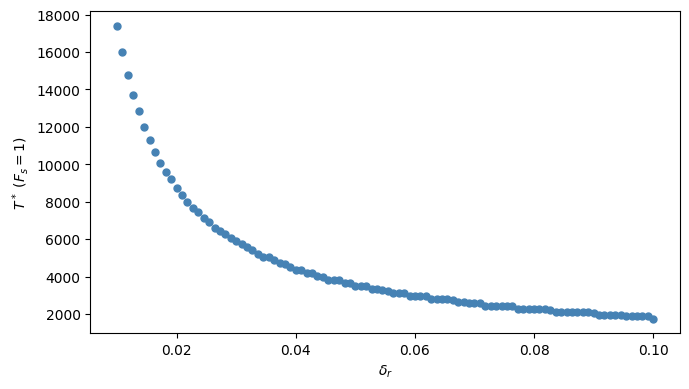

In [58]:
tiempos_recuperacion = []

for d in deltas_r:
    arr = avg_repair[d]
    indices = np.where(arr >= 1.0)[0]
    if len(indices) > 0:
        tiempos_recuperacion.append(indices[0])
    else:
        tiempos_recuperacion.append(np.nan)  # no alcanzó F_s = 1

tiempos_recuperacion = np.array(tiempos_recuperacion)

# --- GRÁFICA ---
plt.figure(figsize=(7, 4))
plt.plot(deltas_r, tiempos_recuperacion, 'o', color='steelblue', linewidth=1.5, markersize=5)
plt.xlabel(r'$\delta_r$')
plt.ylabel(r'$T^*$ ($F_s = 1$)')
plt.tight_layout()
plt.show()


--- Tiempo total: 0.02 minutos ---


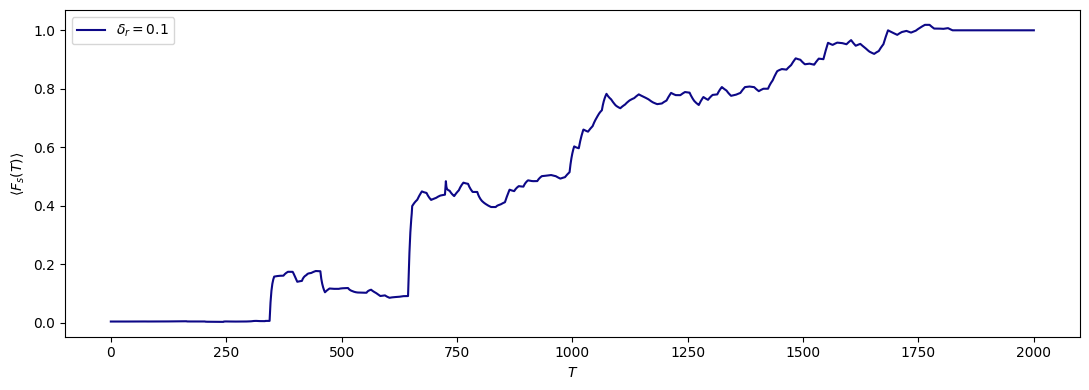

In [60]:
# --- PARÁMETROS ---
num_simulations = 1
T_repair = 2000
#deltas_r = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1])
deltas_r = np.array([0.1])

# --- ACUMULADORES ---
avg_repair = {d: np.zeros(T_repair + 1) for d in deltas_r}

start_time_total = time.time()

# --- BUCLE DE SIMULACIONES ---
for sim in range(num_simulations):
    for d in deltas_r:
        f_repair, Omega_max, F_max = Simulacion_repair_deterministic(A, Omega_damage, T_repair, d, strategy='best')
        avg_repair[d] += f_repair

    if (sim + 1) % 10 == 0:
        print(f"  Simulación {sim+1}/{num_simulations} lista.")

# --- PROMEDIOS ---
for d in deltas_r:
    avg_repair[d] /= num_simulations

print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")

# --- GRÁFICA ---
t_repair = np.arange(T_repair + 1)

colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

plt.figure(figsize=(11, 4))
for d in deltas_r:
    color = colormap(norm(d))
    plt.plot(t_repair, avg_repair[d],
             color=color, linewidth=1.5, label=f'$\\delta_r = {d}$')

plt.xlabel("$T$")
plt.ylabel(r"$\left\langle F_s(T) \right\rangle$")
plt.legend()
plt.tight_layout()
plt.show()

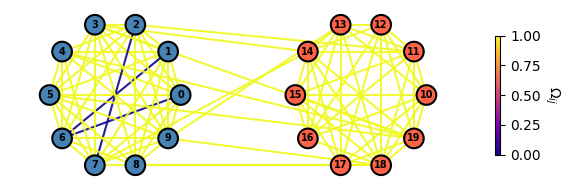

In [61]:
# --- GRÁFICA DE LA RED DAÑADA ---

# 1. Posiciones en dos círculos
N_com = N
pos = {}
for i, node in enumerate(range(N_com)):
    angle = 2 * np.pi * i / N_com
    pos[node] = np.array([-1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])
for i, node in enumerate(range(N_com, 2 * N_com)):
    angle = 2 * np.pi * i / N_com
    pos[node] = np.array([1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])

# 2. Pesos de enlaces
edges = list(G.edges())
weights = np.array([Omega_max[u, v] for u, v in edges])
w_max = weights.max() if weights.max() > 0 else 1

# 3. Dibujar
fig, ax = plt.subplots(figsize=(6, 2))

node_colors = ['steelblue'] * N_com + ['tomato'] * N_com
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=200, node_color=node_colors,
                       edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges,
                       width=1.5,
                       edge_color=weights, edge_cmap=plt.cm.plasma,
                       alpha=0.9, edge_vmin=0, edge_vmax=w_max)

# 4. Barra de color
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=0, vmax=w_max))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label(r'$\Omega_{ij}$', rotation=270, labelpad=15)
ax.axis('off')
plt.tight_layout()
plt.show()